# Week 2 — Day 3: From Prediction to Portfolio

Day 1 tested an MLP on one stock.

Day 2 tested whether an LSTM improved prediction by giving the model memory.

Day 3 asks a different and more important question:

Can those predictions be converted into a portfolio strategy across the full universe that beats the benchmark?


## Week 2 Sources Used

This notebook follows the repository's own Week 2 teaching path:

- `week2/03-form-prediction-to-portfolio/mlp.ipynb`
- `week2/03-form-prediction-to-portfolio/lstm.ipynb`
- `week2/02-lstm/day2_lstm_vs_mlp.ipynb`
- Week 1 backtest/report conventions for benchmarking and metrics

Baseline choices below intentionally match the shared-model Week 2 notebooks before any tuning:

- full `DataFeed.from_dir('data/egx')` universe
- pooled train/test split by calendar day
- MLP hidden size `32`, `150` epochs, Adam, MSE loss, seed `0`
- LSTM hidden size `32`, sequence length `10`, `150` epochs, Adam, MSE loss, seed `0`
- zero commission, equal-weight benchmark, long-only equal weights across all positive predictions


In [1]:
from pathlib import Path
import os
import sys
from textwrap import dedent

repo_root = next(
    path for path in [Path.cwd(), *Path.cwd().parents]
    if (path / "src" / "tradinglab").exists()
)
os.chdir(repo_root)

tmp_dir = repo_root / ".tmp"
(tmp_dir / "matplotlib").mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(tmp_dir / "matplotlib"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

src_path = str(repo_root / "src")
if src_path not in sys.path:
    sys.path.insert(0, src_path)

from tradinglab.data_feed import DataFeed
from tradinglab.day3 import (
    BASELINE_FEATURES,
    build_feature_tensor,
    run_shared_model_portfolio,
)


In [2]:
feed = DataFeed.from_dir("data/egx")
feature_tensor = build_feature_tensor(feed, BASELINE_FEATURES)
split_day = int(feed.n_days * 0.7)
split_date = feed.dates[split_day]
lookback = 30

universe_info = pd.DataFrame(
    {
        "value": [
            feed.n_assets,
            ", ".join(feed.symbols),
            feed.n_days,
            str(feed.dates[0])[:10],
            str(feed.dates[-1])[:10],
            split_day,
            str(split_date)[:10],
        ]
    },
    index=[
        "Number of stocks",
        "Symbols",
        "Number of days",
        "First date",
        "Last date",
        "Train/test split day",
        "Split date",
    ],
)
display(Markdown("## Full Course Universe"))
display(universe_info)

skipped_symbols = []
print("Stocks skipped from modeling:", skipped_symbols or "None")


## Full Course Universe

,value
Number of stocks,34
Symbols,"ABUK, ADIB, ALCN, AMOC, ARCC, BTFH, CCAP, CIEB..."
Number of days,1159
First date,2021-10-20
Last date,2026-07-30
Train/test split day,811
Split date,2025-02-20


Stocks skipped from modeling: None


In [3]:
mlp_baseline = run_shared_model_portfolio(
    feed,
    "mlp",
    feature_names=BASELINE_FEATURES,
    feature_tensor=feature_tensor,
    lookback=lookback,
    hidden=32,
    epochs=150,
    lr=1e-3,
    seed=0,
    commission=0.0,
)

lstm_baseline = run_shared_model_portfolio(
    feed,
    "lstm",
    feature_names=BASELINE_FEATURES,
    feature_tensor=feature_tensor,
    lookback=lookback,
    hidden=32,
    seq_len=10,
    epochs=150,
    lr=1e-3,
    seed=0,
    commission=0.0,
)

mlp_result = mlp_baseline["result"]
lstm_result = lstm_baseline["result"]


In [4]:
mlp_predictions = mlp_result["predictions"]
lstm_predictions = lstm_result["predictions"]
actual_returns = mlp_result["actual_returns"]
mlp_weights = mlp_result["weights"]
lstm_weights = lstm_result["weights"]
common_dates = pd.DatetimeIndex(mlp_result["dates"])
common_signal_dates = pd.DatetimeIndex(mlp_result["signal_dates"])

assert mlp_predictions.shape == lstm_predictions.shape == actual_returns.shape
assert mlp_weights.shape == lstm_weights.shape == actual_returns.shape
assert list(mlp_result["symbols"]) == list(lstm_result["symbols"]) == feed.symbols
assert len(common_dates) == actual_returns.shape[0]
assert len(common_signal_dates) == actual_returns.shape[0]
assert np.all(mlp_weights >= -1e-9) and np.all(lstm_weights >= -1e-9)

mlp_weight_sums = mlp_weights.sum(axis=1)
lstm_weight_sums = lstm_weights.sum(axis=1)
assert np.allclose(mlp_weight_sums[(mlp_weight_sums > 0)], 1.0, atol=1e-6)
assert np.allclose(lstm_weight_sums[(lstm_weight_sums > 0)], 1.0, atol=1e-6)
assert np.allclose(mlp_weight_sums[(mlp_weight_sums == 0)], 0.0, atol=1e-6)
assert np.allclose(lstm_weight_sums[(lstm_weight_sums == 0)], 0.0, atol=1e-6)

alignment_lines = [
    "## Common Out-of-Sample Prediction Matrices",
    "",
    f"- Signal dates run from `{common_signal_dates[0].date()}` to `{common_signal_dates[-1].date()}`",
    f"- Realized return dates run from `{common_dates[0].date()}` to `{common_dates[-1].date()}`",
    f"- Matrix shape: `{mlp_predictions.shape}` = `(days, stocks)`",
    f"- MLP matrix aligned with actual returns: `{mlp_predictions.shape == actual_returns.shape}`",
    f"- LSTM matrix aligned with actual returns: `{lstm_predictions.shape == actual_returns.shape}`",
    f"- Stocks modeled: `{len(mlp_result['symbols'])}`",
]
display(Markdown("\n".join(alignment_lines)))


## Common Out-of-Sample Prediction Matrices

- Signal dates run from `2025-02-20` to `2026-07-29`
- Realized return dates run from `2025-02-23` to `2026-07-30`
- Matrix shape: `(347, 34)` = `(days, stocks)`
- MLP matrix aligned with actual returns: `True`
- LSTM matrix aligned with actual returns: `True`
- Stocks modeled: `34`

In [5]:
comparison = pd.DataFrame(
    [
        {
            "Metric": "Final value",
            "MLP": mlp_result["metrics"]["final_value"],
            "LSTM": lstm_result["metrics"]["final_value"],
            "Benchmark": mlp_result["metrics"]["benchmark_final_value"],
        },
        {
            "Metric": "Total return",
            "MLP": mlp_result["metrics"]["total_return"],
            "LSTM": lstm_result["metrics"]["total_return"],
            "Benchmark": mlp_result["metrics"]["benchmark_return"],
        },
        {
            "Metric": "Sharpe",
            "MLP": mlp_result["metrics"]["sharpe"],
            "LSTM": lstm_result["metrics"]["sharpe"],
            "Benchmark": mlp_result["metrics"]["benchmark_sharpe"],
        },
        {
            "Metric": "Max drawdown",
            "MLP": mlp_result["metrics"]["max_drawdown"],
            "LSTM": lstm_result["metrics"]["max_drawdown"],
            "Benchmark": mlp_result["metrics"]["benchmark_max_drawdown"],
        },
        {
            "Metric": "Excess return",
            "MLP": mlp_result["metrics"]["excess_return"],
            "LSTM": lstm_result["metrics"]["excess_return"],
            "Benchmark": 0.0,
        },
        {
            "Metric": "Average stocks held",
            "MLP": mlp_result["metrics"]["average_stocks_held"],
            "LSTM": lstm_result["metrics"]["average_stocks_held"],
            "Benchmark": float(feed.n_assets),
        },
        {
            "Metric": "Minimum stocks held",
            "MLP": mlp_result["metrics"]["minimum_stocks_held"],
            "LSTM": lstm_result["metrics"]["minimum_stocks_held"],
            "Benchmark": feed.n_assets,
        },
        {
            "Metric": "Maximum stocks held",
            "MLP": mlp_result["metrics"]["maximum_stocks_held"],
            "LSTM": lstm_result["metrics"]["maximum_stocks_held"],
            "Benchmark": feed.n_assets,
        },
        {
            "Metric": "Days invested",
            "MLP": mlp_result["metrics"]["percentage_days_invested"],
            "LSTM": lstm_result["metrics"]["percentage_days_invested"],
            "Benchmark": 1.0,
        },
    ]
).set_index("Metric")
comparison


,MLP,LSTM,Benchmark
Metric,,,
Final value,1.573453,1.571768,1.567198
Total return,0.573453,0.571768,0.567198
Sharpe,2.057016,2.144781,2.132700
Max drawdown,0.086470,0.077753,0.077969
Excess return,0.006256,0.004570,0.000000
Average stocks held,30.668588,33.927954,34.000000
Minimum stocks held,21.000000,32.000000,34.000000
Maximum stocks held,33.000000,34.000000,34.000000
Days invested,1.000000,1.000000,1.000000


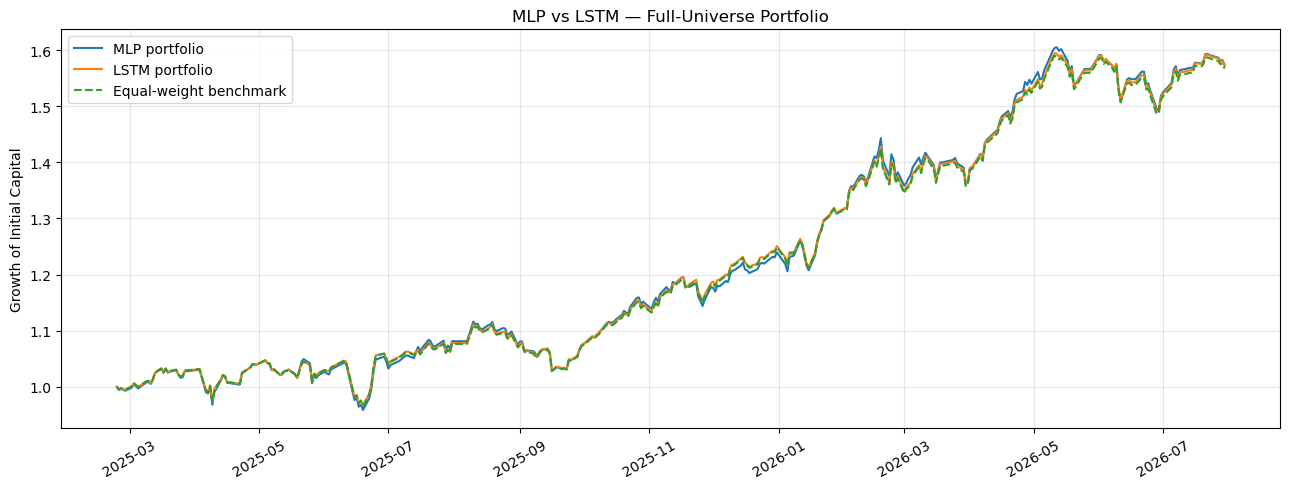

In [6]:
plt.figure(figsize=(13, 5))
plt.plot(common_dates, mlp_result["portfolio"], label="MLP portfolio", linewidth=1.5)
plt.plot(common_dates, lstm_result["portfolio"], label="LSTM portfolio", linewidth=1.5)
plt.plot(common_dates, mlp_result["benchmark"], label="Equal-weight benchmark", linewidth=1.5, linestyle="--")
plt.title("MLP vs LSTM — Full-Universe Portfolio")
plt.ylabel("Growth of Initial Capital")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


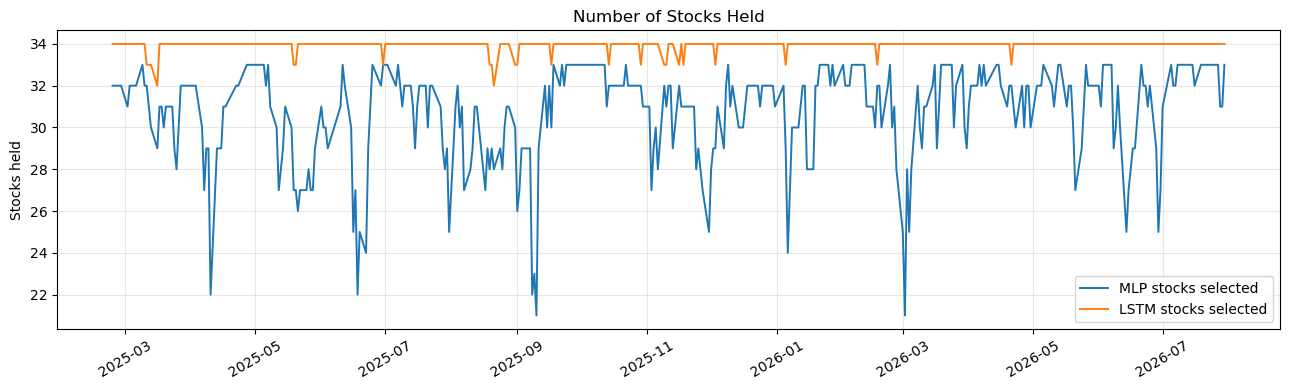

In [7]:
mlp_holdings = (mlp_weights > 1e-6).sum(axis=1)
lstm_holdings = (lstm_weights > 1e-6).sum(axis=1)

plt.figure(figsize=(13, 4))
plt.plot(common_dates, mlp_holdings, label="MLP stocks selected", linewidth=1.4)
plt.plot(common_dates, lstm_holdings, label="LSTM stocks selected", linewidth=1.4)
plt.title("Number of Stocks Held")
plt.ylabel("Stocks held")
plt.grid(alpha=0.3)
plt.legend()
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


In [8]:
mlp_beats_benchmark = mlp_result["metrics"]["final_value"] > mlp_result["metrics"]["benchmark_final_value"]
lstm_beats_benchmark = lstm_result["metrics"]["final_value"] > lstm_result["metrics"]["benchmark_final_value"]
final_value_winner = (
    "MLP"
    if mlp_result["metrics"]["final_value"] > lstm_result["metrics"]["final_value"]
    else "LSTM"
)
lower_drawdown = (
    "MLP"
    if mlp_result["metrics"]["max_drawdown"] < lstm_result["metrics"]["max_drawdown"]
    else "LSTM"
)

baseline_answer = f'''
## Baseline Day 3 Result

- Did MLP beat the benchmark? **{"Yes" if mlp_beats_benchmark else "No"}**.
- Did LSTM beat the benchmark? **{"Yes" if lstm_beats_benchmark else "No"}**.
- Did MLP beat LSTM on final value / total return? **{"Yes" if final_value_winner == "MLP" else "No"}**.
- Did LSTM beat MLP on risk-adjusted behavior? **{"Yes" if lstm_result["metrics"]["sharpe"] > mlp_result["metrics"]["sharpe"] and lstm_result["metrics"]["max_drawdown"] < mlp_result["metrics"]["max_drawdown"] else "No"}**.
- Which had lower drawdown? **{lower_drawdown}**.
- Does the model that predicted ABUK better also create the better diversified portfolio? **No**. The inspected Day 2 ABUK notebook said the LSTM was slightly stronger on the main ABUK price-error metrics, but in this full-universe baseline the MLP finished with the higher final value.

The baseline result is close rather than decisive: the MLP ends a little higher, while the LSTM holds more stocks, posts the slightly better Sharpe ratio, and keeps the lower drawdown.
'''
display(Markdown(dedent(baseline_answer).strip()))


## Baseline Day 3 Result

- Did MLP beat the benchmark? **Yes**.
- Did LSTM beat the benchmark? **Yes**.
- Did MLP beat LSTM on final value / total return? **Yes**.
- Did LSTM beat MLP on risk-adjusted behavior? **Yes**.
- Which had lower drawdown? **LSTM**.
- Does the model that predicted ABUK better also create the better diversified portfolio? **No**. The inspected Day 2 ABUK notebook said the LSTM was slightly stronger on the main ABUK price-error metrics, but in this full-universe baseline the MLP finished with the higher final value.

The baseline result is close rather than decisive: the MLP ends a little higher, while the LSTM holds more stocks, posts the slightly better Sharpe ratio, and keeps the lower drawdown.

In [9]:
validation_text = '''
## Validation Against Required Reference Files

- `week1/06-tiktok-strategy/tiktok_strategy.py`: same `DataFeed.from_dir('data/egx')`, same `PortfolioSimulator` accounting contract, same long-only weight matrix shape, and the same realized-date convention where weights chosen on day `t` earn return `t -> t+1`.
- `week2/03-form-prediction-to-portfolio/mlp.ipynb`: same pooled shared-model training, same hidden size `32`, same seed `0`, same `150` epochs, same Adam + MSE training helper, and the same equal-weight benchmark with zero commission.
- `week2/03-form-prediction-to-portfolio/lstm.ipynb`: same pooled sequence training, same hidden size `32`, same sequence length `10`, same seed `0`, same `150` epochs, and the same Week 2 benchmark/cost conventions.

Transaction costs are intentionally **0.0** here because that is the direct Week 2 baseline convention in the referenced MLP/LSTM notebooks.
'''
display(Markdown(dedent(validation_text).strip()))


## Validation Against Required Reference Files

- `week1/06-tiktok-strategy/tiktok_strategy.py`: same `DataFeed.from_dir('data/egx')`, same `PortfolioSimulator` accounting contract, same long-only weight matrix shape, and the same realized-date convention where weights chosen on day `t` earn return `t -> t+1`.
- `week2/03-form-prediction-to-portfolio/mlp.ipynb`: same pooled shared-model training, same hidden size `32`, same seed `0`, same `150` epochs, same Adam + MSE training helper, and the same equal-weight benchmark with zero commission.
- `week2/03-form-prediction-to-portfolio/lstm.ipynb`: same pooled sequence training, same hidden size `32`, same sequence length `10`, same seed `0`, same `150` epochs, and the same Week 2 benchmark/cost conventions.

Transaction costs are intentionally **0.0** here because that is the direct Week 2 baseline convention in the referenced MLP/LSTM notebooks.